# Proyecto FACULTADES

Clasificacion de resumenes segun la facultad.

Clases:
- administracion_empresas
- medicina
- gobierno
- derecho
- economia

Métrica: F1 macro. Economia tiene pocos ejemplos pero cuenta igual que las otras.

Este notebook tiene TF-IDF y logistic regression, importante que el grupo valide mas modelos.

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)

## 1. Cargar datos

Los csv están en inputs. Si lo corro en Colab cambio la ruta.

In [3]:
DATA_DIR = "inputs"

df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
df_val = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
df_test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(df_train.shape, df_val.shape, df_test.shape)
df_train.head()

(6000, 3) (1500, 3) (4937, 2)


,id,resumen,facultad
0,TR-00001,Introducción: Dado que la enfermedad cardiovas...,medicina
1,TR-00002,Los Exchange Traded-Funds (ETFs) se han conver...,economia
2,TR-00003,Introducción: La hipertensión portal se define...,medicina
3,TR-00004,El direccionamiento estratégico está destinado...,administracion_empresas
4,TR-00005,En esta monografía se analizará la importancia...,gobierno


## 2. Exploración

Primero miro nulos, cómo están las clases y qué tan largos son los textos.

In [4]:
print(df_train.columns.tolist())
print(df_train.dtypes)
print("\nNulos train:")
print(df_train.isna().sum())
print("\nNulos val:")
print(df_val.isna().sum())
print("\nNulos test:")
print(df_test.isna().sum())

['id', 'resumen', 'facultad']
id          str
resumen     str
facultad    str
dtype: object

Nulos train:
id          0
resumen     0
facultad    0
dtype: int64

Nulos val:
id          0
resumen     0
facultad    0
dtype: int64

Nulos test:
id         0
resumen    0
dtype: int64


Train
facultad
administracion_empresas    1830
medicina                   1783
gobierno                   1255
derecho                     776
economia                    356
Name: count, dtype: int64

Val
facultad
administracion_empresas    457
medicina                   446
gobierno                   314
derecho                    194
economia                    89
Name: count, dtype: int64


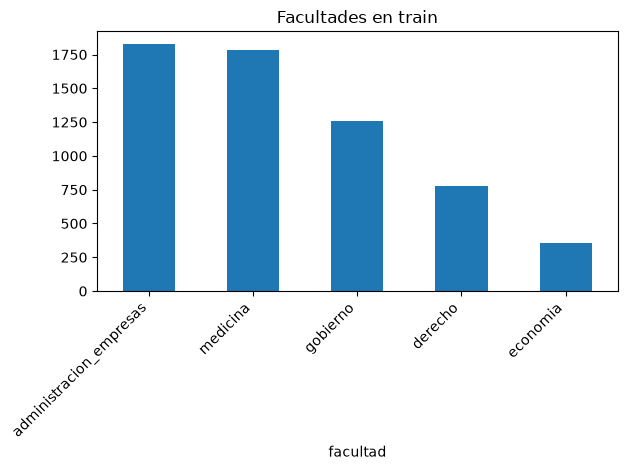

In [5]:
print("Train")
print(df_train["facultad"].value_counts())
print("\nVal")
print(df_val["facultad"].value_counts())

df_train["facultad"].value_counts().plot(kind="bar")
plt.title("Facultades en train")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
df_train["n_palabras"] = df_train["resumen"].astype(str).str.split().str.len()
print(df_train["n_palabras"].describe())

df_train.groupby("facultad")["n_palabras"].median()

count    6000.000000
mean      186.098167
std       132.362864
min        20.000000
25%       104.000000
50%       166.000000
75%       245.000000
max      3320.000000
Name: n_palabras, dtype: float64


facultad
administracion_empresas    166.5
derecho                    126.5
economia                   145.0
gobierno                   122.0
medicina                   242.0
Name: n_palabras, dtype: float64

In [7]:
# un ejemplo por clase, para ver cómo se escriben
for fac in df_train["facultad"].unique():
    texto = df_train[df_train["facultad"] == fac]["resumen"].iloc[0]
    print("====", fac, "====")
    print(texto[:400])
    print()

==== medicina ====
Introducción: Dado que la enfermedad cardiovascular (ECV) es la causa más común de mortalidad en pacientes con artritis reumatoide (AR), el objetivo fue determinar los factores asociados a esta complicación en una serie amplia de pacientes colombianos. Adicionalmente, se efectuó una revisión sistemática de la literatura para abordar el estado del arte sobre los factores de riesgo no tradicionales 

==== economia ====
Los Exchange Traded-Funds (ETFs) se han convertido en una de las posibilidades más llamativas para inversores alrededor del mundo. La posibilidad de realizar una sola inversión con el riesgo ya diversificado y la facilidad que presentan los ETFs, ha hecho que el número de estos se haya disparado en el mercado, por lo que la estimación y anticipación de estos activos ha adquirido una gran importanc

==== administracion_empresas ====
El direccionamiento estratégico está destinado para que las organizaciones cumplan con sus metas y tengan perdurabilidad en 

## 3. Preprocesamiento

Los textos estan crudos. Por ahora solo paso a minusculas y quito espacios de más. El tfidf hace el resto.

Ojo: el vocabulario lo armo con train (despues con train+val). El test no lo uso para entrenar.

In [8]:
def limpiar_texto(texto):
    texto = str(texto)
    texto = texto.lower()
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

X_train = df_train["resumen"].map(limpiar_texto)
y_train = df_train["facultad"]

X_val = df_val["resumen"].map(limpiar_texto)
y_val = df_val["facultad"]

X_test = df_test["resumen"].map(limpiar_texto)

X_train.iloc[0][:300]

'introducción: dado que la enfermedad cardiovascular (ecv) es la causa más común de mortalidad en pacientes con artritis reumatoide (ar), el objetivo fue determinar los factores asociados a esta complicación en una serie amplia de pacientes colombianos. adicionalmente, se efectuó una revisión sistemá'

## 4. Modelo

TF-IDF con unigramas y bigramas. Puse class_weight balanced porque economia y derecho tienen menos datos y el F1 macro las trata igual.

In [9]:
modelo = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        class_weight="balanced",
    )),
])

modelo.fit(X_train, y_train)
pred_val = modelo.predict(X_val)

print("F1 macro val:", f1_score(y_val, pred_val, average="macro"))
print()
print(classification_report(y_val, pred_val))

F1 macro val: 0.850402772792601

                         precision    recall  f1-score   support

administracion_empresas       0.90      0.90      0.90       457
                derecho       0.80      0.78      0.79       194
               economia       0.77      0.79      0.78        89
               gobierno       0.84      0.88      0.86       314
               medicina       0.94      0.91      0.92       446

               accuracy                           0.88      1500
              macro avg       0.85      0.85      0.85      1500
           weighted avg       0.88      0.88      0.88      1500



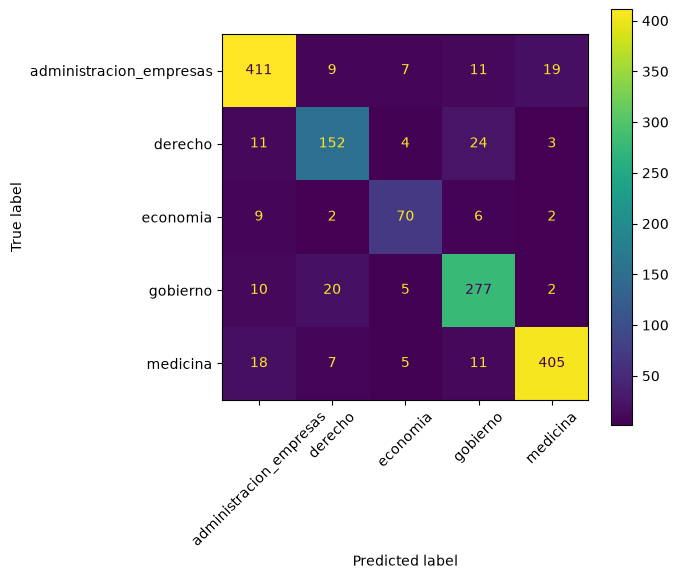

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    pred_val,
    xticks_rotation=45,
    ax=ax,
)
plt.tight_layout()
plt.show()

## 5. Submission

Entreno con train+val y armo el csv para Kaggle.

In [11]:
X_final = pd.concat([X_train, X_val], ignore_index=True)
y_final = pd.concat([y_train, y_val], ignore_index=True)

modelo_final = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        class_weight="balanced",
    )),
])

modelo_final.fit(X_final, y_final)
pred_test = modelo_final.predict(X_test)

submission = pd.DataFrame({
    "id": df_test["id"],
    "facultad": pred_test,
})

print(submission.head())
print(submission["facultad"].value_counts())
print("filas:", len(submission))

submission.to_csv("submission.csv", index=False)
print("\nArchivo guardado: submission.csv")

         id                 facultad
0  TS-00001                 medicina
1  TS-00002                 medicina
2  TS-00003                  derecho
3  TS-00004  administracion_empresas
4  TS-00005                 gobierno
facultad
administracion_empresas    1531
medicina                   1458
gobierno                   1074
derecho                     610
economia                    264
Name: count, dtype: int64
filas: 4937

Archivo guardado: submission.csv
